# Plotting Your Data
----
To start out, you'll want to load your data from a file using numpy, and then put it into a dataframe using Pandas.  This makes the data much easier to work with as we'll need to select sub-sets of it frequently.

To start off, we'll set up the `ipympl` backend, which 

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
#%matplotlib widget
# Change the backend to 'notebook' if this isn't functional.
%matplotlib inline
data_filename = "smileplease_Oct25_Time_22_29_39.csv"

In [2]:
d = np.loadtxt(data_filename, delimiter=',',dtype = np.int32)
data = pd.DataFrame(d, columns = ['x','theta','t','ch1','ch2','counts'])
data['rate'] = data['counts']/data['t']
display(data)
angles = data['theta'].unique()
print(angles)

,x,theta,t,ch1,ch2,counts,rate
0,900,0,10,29602,29708,407,40.7
1,1400,0,10,29045,29884,340,34.0
2,1900,0,10,29242,30171,389,38.9
3,2400,0,10,29426,30117,360,36.0
4,2900,0,10,29808,30272,388,38.8
...,...,...,...,...,...,...,...
10795,88400,18880,10,6421,28485,694,69.4
10796,88900,18880,10,6343,28450,666,66.6
10797,89400,18880,10,6169,28465,677,67.7
10798,89900,18880,10,6478,28191,688,68.8


[    0   320   640   960  1280  1600  1920  2240  2560  2880  3200  3520
  3840  4160  4480  4800  5120  5440  5760  6080  6400  6720  7040  7360
  7680  8000  8320  8640  8960  9280  9600  9920 10240 10560 10880 11200
 11520 11840 12160 12480 12800 13120 13440 13760 14080 14400 14720 15040
 15360 15680 16000 16320 16640 16960 17280 17600 17920 18240 18560 18880]


This should show several rows of a table, and the ``unique()`` function will select out the values of the individual angles that are in the dataset.

We'll use this to make a set of plots for each angle.  It'll be messy at first, but it gives a brief bit of insight into what you've got.

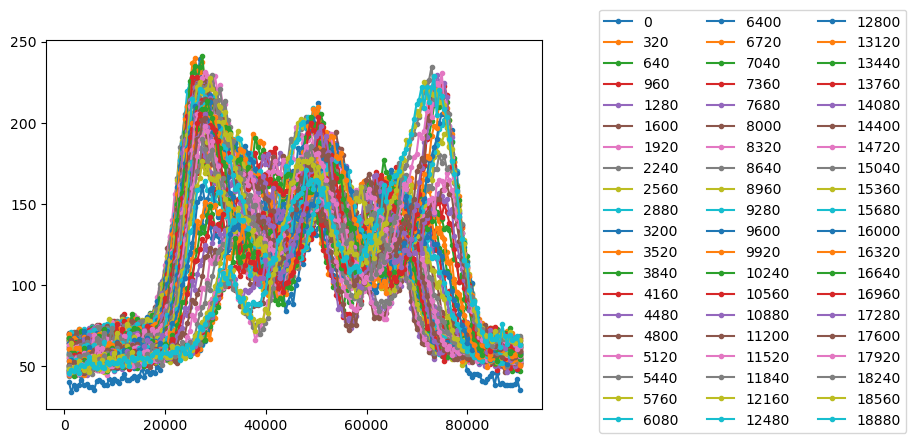

In [3]:
fig,ax = plt.subplots()
for a in angles:
    x_val = data[data['theta']==a]['x'].values
    rate_val = data[data['theta']==a]['rate'].values
    # Newer versions of Matplotlib can work with Pandas series natively, but this ensures backwards compatability.
    ax.plot(x_val,rate_val,label=a,marker='.')
plt.legend(ncol=3,bbox_to_anchor=(1.1, 1.1))
plt.show()

Now, there's the obvious problem that we want ultimately want to work with spatial variables, not arbitrary position values.  **To this end, you'll need to identify what value corresponds to the platform being centered between the detectors and change the ``center`` variable to reflect that.**
You'll also want to convert your distances to units of length at some point, and your angles to units of degrees. **Set the ``length_conversion`` value appropriately.**

In [4]:
center = 50000
length_conversion = 5000 # converts to cm
angle_conversion = 25600/360 #25600 motor pulses complete one full rotation
data['xcenter'] = (data['x'] - center)
data['xconverted'] = data['xcenter']/length_conversion
data['thetaconverted'] = data['theta']/angle_conversion
display(data)

,x,theta,t,ch1,ch2,counts,rate,xcenter,xconverted,thetaconverted
0,900,0,10,29602,29708,407,40.7,-49100,-9.82,0.0
1,1400,0,10,29045,29884,340,34.0,-48600,-9.72,0.0
2,1900,0,10,29242,30171,389,38.9,-48100,-9.62,0.0
3,2400,0,10,29426,30117,360,36.0,-47600,-9.52,0.0
4,2900,0,10,29808,30272,388,38.8,-47100,-9.42,0.0
...,...,...,...,...,...,...,...,...,...,...
10795,88400,18880,10,6421,28485,694,69.4,38400,7.68,265.5
10796,88900,18880,10,6343,28450,666,66.6,38900,7.78,265.5
10797,89400,18880,10,6169,28465,677,67.7,39400,7.88,265.5
10798,89900,18880,10,6478,28191,688,68.8,39900,7.98,265.5


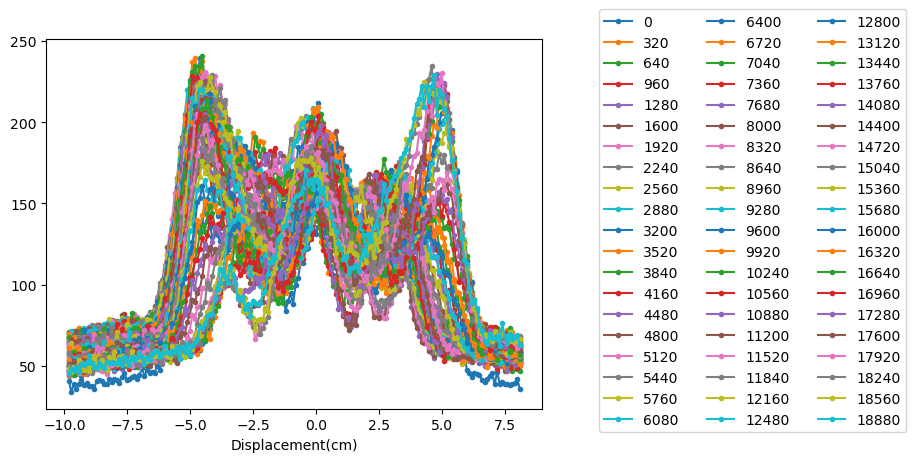

In [5]:
data_by_angle = []
fig,ax = plt.subplots()
for a in angles:
    x_val = data[data['theta']==a]['xconverted'].values
    rate_val = data[data['theta']==a]['rate'].values
    ax.plot(x_val,rate_val,label=a,marker='.')
ax.set_xlabel("Displacement(cm)")
plt.legend(ncol=3,bbox_to_anchor=(1.1, 1.1))
plt.show()

Well, now that we have the dimensions figured out, let's convert this series of 1d plots into a 2d plot of position versus angle.

To do this, we'll use the ``pivot_table`` function to select out the coincidence counts in terms of the converted $\theta$ and $x$ variables.  

If you want a bit of an explanation of what this does, see the [pivot table wikipedia page](https://en.wikipedia.org/wiki/Pivot_table#Mechanics).

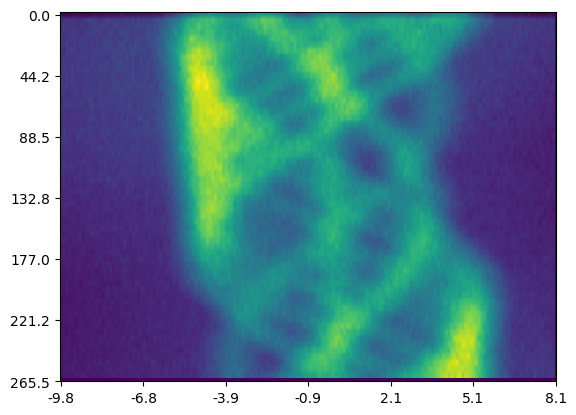

In [6]:
fig,ax = plt.subplots()
sinogram = data.pivot_table('rate', 'thetaconverted', 'xconverted', fill_value=0).values
ax.imshow(sinogram,aspect="auto")

# The rest of this gets a list of the angles & positions we're using so that we can scale the plot appropriately.
positions = data.pivot_table('rate', 'thetaconverted', 'xconverted', fill_value=0).keys() 
angle_vals =  data.pivot_table('rate', 'xconverted','thetaconverted', fill_value=0).keys()

n_x_ticks = 7 # adjust as needed
n_y_ticks = 7 # adjust as needed

x_tick_labels = np.linspace(positions[0],positions[-1],n_x_ticks).round(1)
y_tick_labels = np.linspace(angle_vals[0],angle_vals[-1],n_y_ticks).round(1)
# By default, this will give us seven ticks on each axis equally spaced apart and rounded to one decimal place.

ax.set_xticks(np.linspace(0,len(sinogram[0]),n_x_ticks))
ax.set_xticklabels(x_tick_labels)

ax.set_yticks(np.linspace(0,len(sinogram),n_y_ticks))
ax.set_yticklabels(y_tick_labels)
# Newer versions of Matplotlib let you set ticks and labels at the same time.  Again, this is for compatability.

# The following changes the edges of the plot to a dark blue instead of bright white
default_bkg = [0.267004, 0.004874, 0.329415]
ax.set_facecolor(default_bkg)

plt.show()

Now, let's look how this plot corresponds to our previous ones.  After shamelessly stealing from one of the [Matplotlib Tutorials](https://matplotlib.org/stable/tutorials/intermediate/arranging_axes.html), we can set up our sinogram plot side-by-side with some of the individual scans.  If how the two correlate isn't clear, talk with your TA or the lab staff to make sure you understand what's going on.

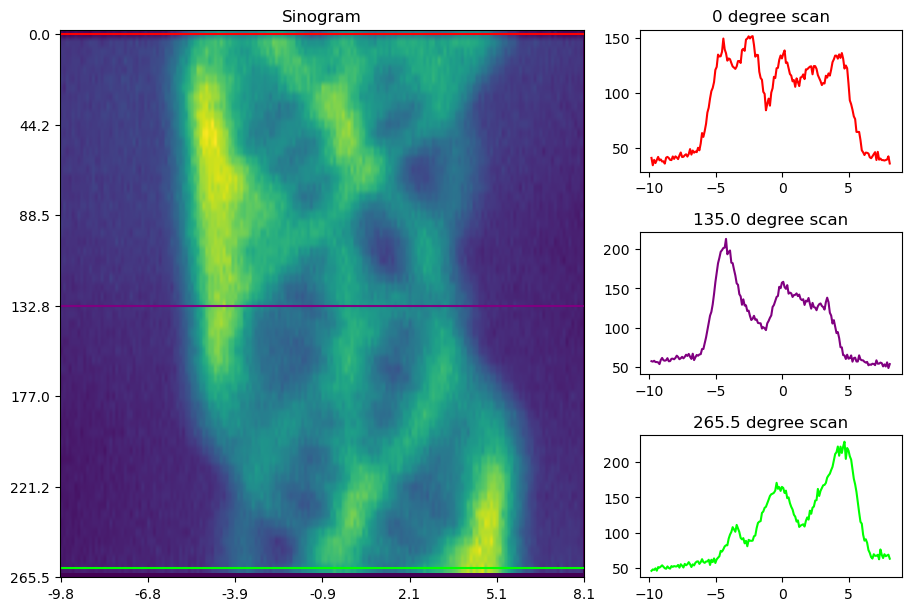

In [7]:
fig = plt.figure(figsize = (9,6) ,constrained_layout=True)
spec = fig.add_gridspec(3, 3)

ax = fig.add_subplot(spec[:,:2])
sinogram = data.pivot_table('rate', 'thetaconverted', 'xconverted', fill_value=0).values
ax.set_title("Sinogram")
ax.imshow(sinogram,aspect="auto")
positions = data.pivot_table('rate', 'thetaconverted', 'xconverted', fill_value=0).keys() 
angle_vals =  data.pivot_table('rate', 'xconverted','thetaconverted', fill_value=0).keys()

n_x_ticks = 7 # adjust as needed
n_y_ticks = 7 # adjust as needed

x_tick_labels = np.linspace(positions[0],positions[-1],n_x_ticks).round(1)
y_tick_labels = np.linspace(angle_vals[0],angle_vals[-1],n_y_ticks).round(1)

ax.set_xticks(np.linspace(0,len(sinogram[0]),n_x_ticks))
ax.set_xticklabels(x_tick_labels)
ax.set_yticks(np.linspace(0,len(sinogram),n_y_ticks))
ax.set_yticklabels(y_tick_labels)
ax.set_facecolor(default_bkg)


ax0 = fig.add_subplot(spec[0, 2])
ax0.plot(data[data['thetaconverted']==angle_vals[0]]['xconverted'].values, sinogram[0],color='red')
ax0.set_title("0 degree scan")
ax.axhline(0,color='red')

axm = fig.add_subplot(spec[1, 2])
axm.plot(data[data['thetaconverted']==angle_vals[len(angle_vals)//2]]['xconverted'].values, sinogram[len(angle_vals)//2],color='purple')
axm.set_title("{} degree scan".format(angle_vals[len(angle_vals)//2]))
ax.axhline(len(angle_vals)//2,color='purple')

axf = fig.add_subplot(spec[2, 2])
axf.plot(data[data['thetaconverted']==angle_vals[-1]]['xconverted'].values, sinogram[-1],color='lime')
axf.set_title("{} degree scan".format(angle_vals[-1]))
ax.axhline(len(angle_vals)-1,color='lime');

plt.show()

Now, if your scan is asymmetric, we'll need to do something to make the matrix properly symmetric.  We need to ensure that the middle point of the platter is the middle of the matrix, otherwise we'll smear out our points into crescents.  To do that, we'll count up how many datapoints there are to the left and right of the x=0 position.  We'll then pad out the sinogram matrix to square up our dataset.

This may very well not do anything to your dataset, so don't be worried if nothing happens.

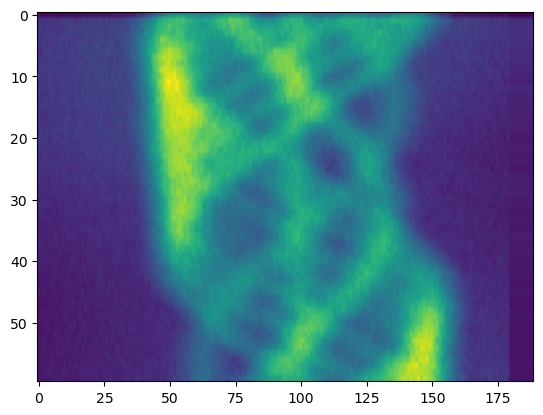

In [8]:
left = sum(data['xconverted'].unique()<0)
right = sum(data['xconverted'].unique()>0)
pad_amt = (left- right)//2

if pad_amt > 0:
    sinogram = np.pad(sinogram, ((0,0),(0,pad_amt)),'minimum')
elif pad_amt < 0 :
    sinogram = np.pad(sinogram, ((0,0),(-1*pad_amt,0)),'minimum')
fig,ax = plt.subplots()
ax.imshow(sinogram,aspect='auto')
plt.show()

Now we have an inverse problem:  We know what the intensity of our source looks like as a function of distance and angle, but we want to know it in terms of x and y position in platform coordinates.

There are a number of ways we can go about doing this, but we'll start with the simplest first: projecting out our slices along the line of response for the detectors, rotating these projections by their associated angles, and then combining all these together to get a composite plot.

To project out out slices, we'll use `np.outer` to do an outer product; this turns our 1d slices into 2d matricies.

The code below does this for each slice in our data, and plots the results for the first and second slices.

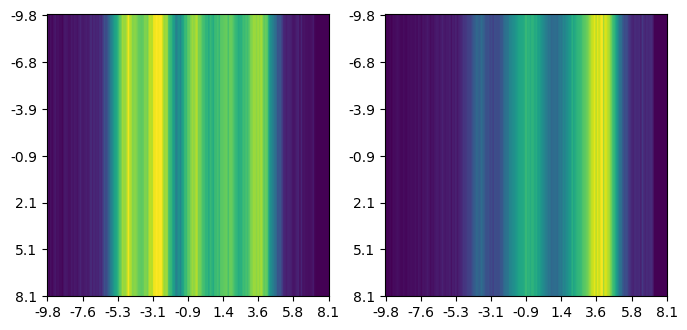

In [9]:
from scipy import ndimage
expanded_data = []
for item in sinogram:
    expand_vec = np.ones(item.size)  # this is used to get us a square matrix
    expanded_data.append(np.outer(expand_vec,item))
    
fig, (ax,ay) = plt.subplots(1,2,figsize= (8,4))
ax.imshow(expanded_data[0])
positions = data.pivot_table('rate', 'thetaconverted', 'xconverted', fill_value=0).keys() 
n_x_ticks = 9 # adjust as needed

x_tick_labels = np.linspace(positions[0],positions[-1],n_x_ticks).round(1)
y_tick_labels = np.linspace(positions[0],positions[-1],n_y_ticks).round(1)

ax.set_xticks(np.linspace(0,len(expanded_data[0]),n_x_ticks))
ax.set_xticklabels(x_tick_labels)
ax.set_yticks(np.linspace(0,len(expanded_data[0]),n_y_ticks))
ax.set_yticklabels(y_tick_labels)
ax.set_facecolor(default_bkg)

ay.imshow(expanded_data[-1])

ay.set_xticks(np.linspace(0,len(expanded_data[0]),n_x_ticks))
ay.set_xticklabels(x_tick_labels)
ay.set_yticks(np.linspace(0,len(expanded_data[0]),n_y_ticks))
ay.set_yticklabels(y_tick_labels)
ay.set_facecolor(default_bkg)
plt.show()

One more issue we get into here: we'll want to rotate our data to overlay the scans, but first we need to be sure that we're rotating around the platform's axis (i.e. $x = 0$).  If we don't do this, then our reconstruction will smear everything out more and more the further off-axis we are.

To do this, we find the smallest positive `x` value in each slice and subtract it off of all the position values.

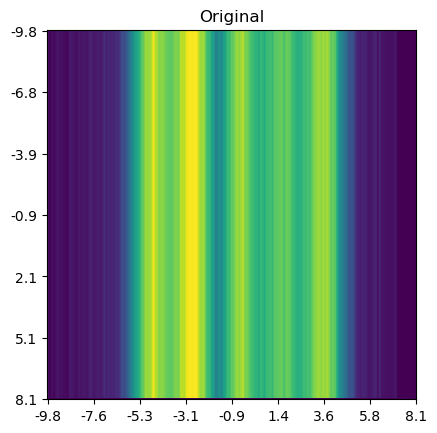

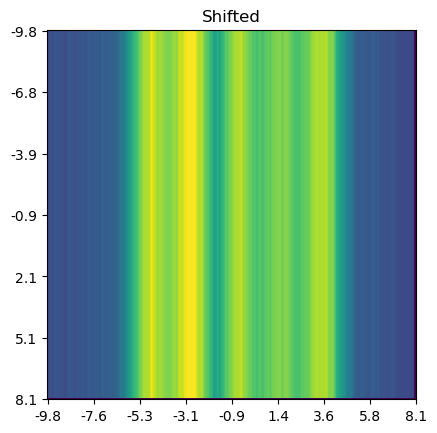

In [10]:
fig,ax = plt.subplots()

a=0
dshift = data.query('theta == {}'.format(a))['xconverted']
shift_value = dshift[len(dshift)//2]

ax.imshow(expanded_data[0])

ax.set_xticks(np.linspace(0,len(expanded_data[0]),n_x_ticks))
ax.set_xticklabels(x_tick_labels)
ax.set_yticks(np.linspace(0,len(expanded_data[0]),n_y_ticks))
ax.set_yticklabels(y_tick_labels)
ax.set_facecolor(default_bkg)

ax.set_title("Original")

fig, ax = plt.subplots()
ax.imshow(ndimage.shift(expanded_data[0],(0,shift_value)))
ax.set_title("Shifted")

ax.set_xticks(np.linspace(0,len(expanded_data[0]),n_x_ticks))
ax.set_xticklabels(x_tick_labels)
ax.set_yticks(np.linspace(0,len(expanded_data[0]),n_y_ticks))
ax.set_yticklabels(y_tick_labels)
ax.set_facecolor(default_bkg)

shifted_data = np.empty_like(expanded_data)
for index,item in enumerate(expanded_data):
    shifted_data[index] = ndimage.shift(item,(0,shift_value))
plt.show()

Okay, we've made 2d representations of each slice, and we've figured out how to properly add an offset to the axes.  Now how do we rotate them?  Instead of writing code to do matrix rotation ourselves, we'll use scipy's `ndimage` library.  Unless you manually want to write a matrix rotation algorithm.  I'm not your boss, knock yourself out.

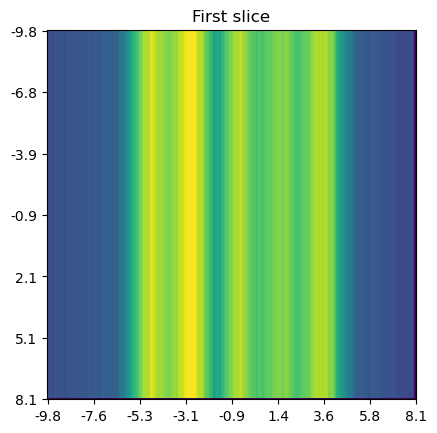

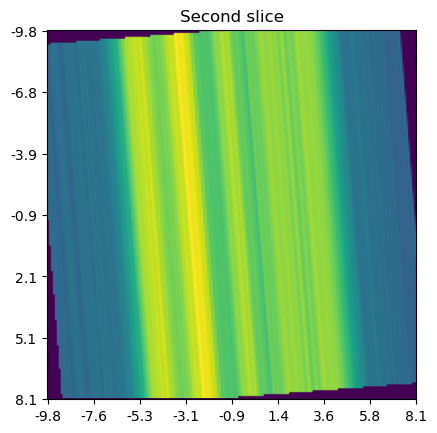

In [11]:
rotated_data = []
for index, item in enumerate(shifted_data):
    rotated_data.append(ndimage.rotate(item,angle_vals[index],reshape=False)) # we want Numpy to keep our square, 2d matricies.
    
fig, ax = plt.subplots()
ax.imshow(rotated_data[0])
ax.set_title("First slice")

ax.set_xticks(np.linspace(0,len(sinogram[0]),n_x_ticks))
ax.set_xticklabels(x_tick_labels)
ax.set_yticks(np.linspace(0,len(sinogram[0]),n_y_ticks))
ax.set_yticklabels(y_tick_labels)
ax.set_facecolor(default_bkg)

fig, ay = plt.subplots()
ay.imshow(rotated_data[1]) 
ay.set_title("Second slice")

ay.set_xticks(np.linspace(0,len(sinogram[0]),n_x_ticks))
ay.set_xticklabels(x_tick_labels)
ay.set_yticks(np.linspace(0,len(sinogram[0]),n_y_ticks))
ay.set_yticklabels(y_tick_labels)
ay.set_facecolor(default_bkg)

plt.show()

The rotated part has some bad aliasing going on, but it more-or-less captures the results of our second scan.  We'll show how to reduce that a bit later, but for now let's start recombining data!

To do this, we'll make a composite image by adding together the coincidence counts for each of these expanded & rotated slices.  Locations where we don't see many coincidences at any angle will end up with low counts, and locations with lots of coincidences at similar angles will end up with high counts.  It may be easier to see what this looks like, so let's start by recombining just the first and third slices.

We'll also normalize the data by dividing by `n`, where `n` is the number of slices we're using.

----
For starters, let's add the first and last rotations together

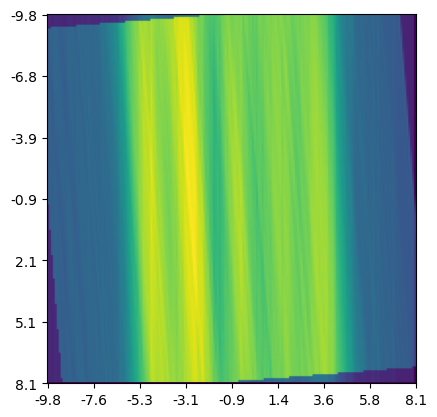

In [12]:
composite = rotated_data[0] + rotated_data[1]
normalized = composite/2

fig, ax = plt.subplots()
ax.imshow(normalized)
ax.set_xticks(np.linspace(0,len(sinogram[0]),n_x_ticks))
ax.set_xticklabels(x_tick_labels)
ax.set_yticks(np.linspace(0,len(sinogram[0]),n_y_ticks))
ax.set_yticklabels(y_tick_labels)
ax.set_facecolor(default_bkg)
plt.show()

If you have more than one source, you might notice that there are multiple areas corresponding to high intensities here.  That's because there are cross-terms where one source's maximum lines up with a different source.  Thankfully, this effect can be mitigated by adding in more rotations, which will supress the 'ghost' peaks. Let's do that now.

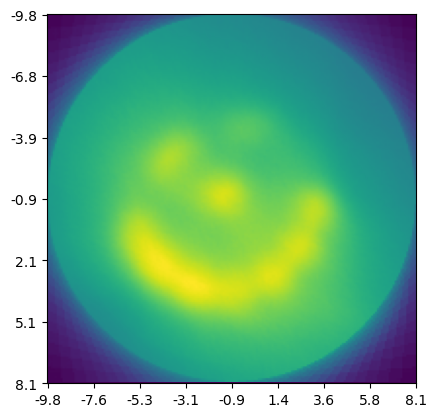

In [13]:
composite = np.zeros_like(rotated_data[0]) # We need a matrix full of 1s to start out with, we can't multiply an empty matrix with anything.
for item in rotated_data:
    composite += item
normalized = composite/len(rotated_data) #

fig, ax = plt.subplots()
ax.imshow(normalized)
ax.set_xticks(np.linspace(0,len(sinogram[0]),n_x_ticks))
ax.set_xticklabels(x_tick_labels)
ax.set_yticks(np.linspace(0,len(sinogram[0]),n_y_ticks))
ax.set_yticklabels(y_tick_labels)
ax.set_facecolor(default_bkg)
plt.show()

----
# Localizing the sources 
Now, let's get to locating sources.  As you've probably noticed, the mouseover display currently only gives the $z$ value of the point under the cursor.  However, if we disable our tick marks, we'll get the ability to read out the position in array values.  Let's check it out.

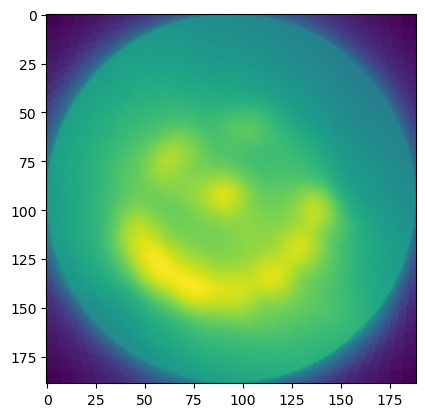

In [14]:
fig, ax = plt.subplots()
ax.imshow(normalized)
ax.set_facecolor(default_bkg)
plt.show()

For this example, it looks like the rightmost source is centered around $x = 134$, $y = 100$, and has an intensity of $z=154$.  What does that mean?
Well, we would expect it should mean that if we look at the array of our data `normalized`, the 134th column and 100th row will have a value of 154.  Let's try.


In [15]:
print(normalized[134,100])

156.04934395248438


That wasn't quite right, what gives?
Well, it turns out that the arrays we're working with use the first index for the row and the second for the column.  To fix that, we can either swap the order we're asking for them, or transpose the entire array with the `.T` suffix.  I prefer the latter at this stage because it lets me read off the same values in the same order, but it *is* computationally inefficient.

In [16]:
print(normalized[100,134])
print(normalized.T[134,100])

153.6318560729027
153.6318560729027


Okay, with that taken care of let's zoom in a bit.  Note that if you're transposing the array to select elements, you'll have to transpose it back to keep from flipping the image.  Once again we'll show both ways.

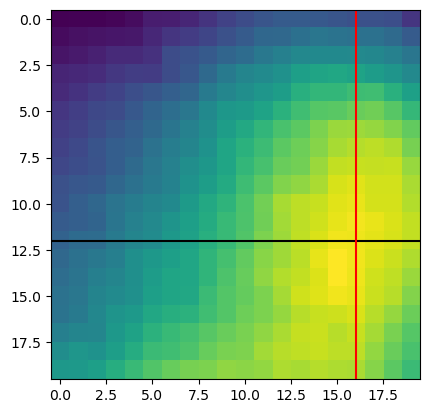

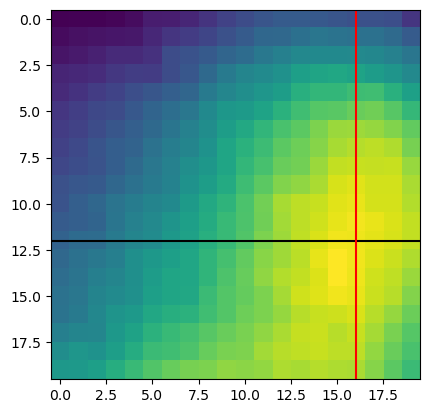

In [17]:
fig, ax = plt.subplots()
ax.imshow(normalized.T[120:140,90:110].T)
ax.set_facecolor(default_bkg)
ax.axhline(12,c='k')
ax.axvline(16,c='r')

fig, ax = plt.subplots()
ax.imshow(normalized[90:110,120:140])
ax.set_facecolor(default_bkg)
ax.axhline(12,c='k')
ax.axvline(16,c='r')
plt.show()

I've added annotations for showing (approximately) where the center of the distribution is here.  It looks like the center of this is at around `16,12`.  So, let's look at some 1D slices of this data.  We'll add together our new offsets to the starting values of the subset here, but basically we're right back to looking at row `136`, column `102`.  We're going to do a bit of `numpy` magic here to get a column of data (the red line).  If we use the syntax of `[::,z]` then numpy will first apply no filter to the rows (the `::` tells it that you don't have a start,end, or increment value in mind) and the `,z` tells it we're filtering by just the one column.  Not critical data for this class, but it will make you more adept at working with multidimensional data wiyh Python.

155.15738762585858


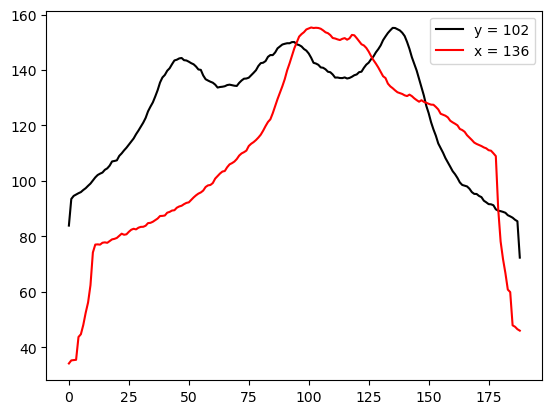

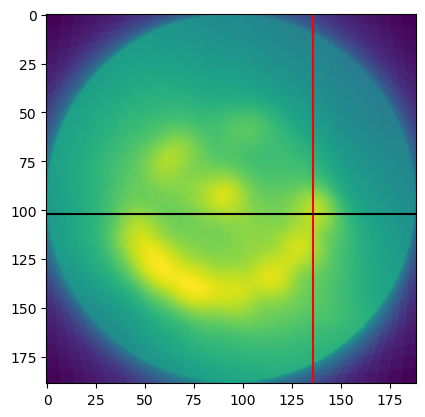

In [18]:
fig, ax = plt.subplots()
ax.plot(normalized[90+12],'k',label='y = 102')
ax.plot(normalized[::,120+16],'r',label='x = 136')
ax.legend()

fig, ax = plt.subplots()
ax.imshow(normalized)
ax.set_facecolor(default_bkg)
ax.axvline(120+16,c='r')
ax.axhline(90+12,c='k')

print(normalized[102,136])
plt.show()

You can figure out what to do with the rest of the data here to best figure out the distribution's center.  Now, you might also want to know how to convert back to units of distance rather than array values.  Thankfully, we've forced things into a 2D array and imposed some symmetry, so the conversion for `x` and `y` is the same.  What is that conversion?  The `positions` array!  Let's take a look.

In [19]:
print("x = ",positions[136],"cm")
print("y = ",positions[102],"cm")

x =  3.78 cm
y =  0.38 cm


Hmm, that's close, but the `y` value is flipped from our original plot.  It turns out that that's due to `ax.imshow` starting from the top left corner!  To fix it, just negate the `y` coordinate.

In [20]:
print("x = ",positions[136],"cm")
print("y = ",-1*positions[102],"cm")

x =  3.78 cm
y =  -0.38 cm


What's that you say?  You did a fit and you need to interpolate between positions?  Fine, we can do that. let's suppose your distribution centers around the x coordinate `136.3`.  Here are two equivalent ways of doing a linear interpolation.  If you really wanted to calculate the decimal part, you could have numpy find the `np.floor` of our value(i.e. rounding down to the nearest integer) and then subtract that from our original value.  Knock yourself out.

In [21]:
base = 136
d = 0.3

print("x = {:.2f}cm".format(((1 - d) * positions[base] + (d) * positions[base+1])))

print("x = {:.2f}cm".format(positions[base]+d*(positions[base+1]-positions[base])))

x = 3.81cm
x = 3.81cm


There you have it, unit conversion at its finest!  
# Back to your regularly scheduled notebook.

----

While likely quite blurry, you should have something that now at least vaguely resembles a few point sources.  Congratulations, you've now got the basics down!

Wait, you want to see the intermediate steps?  Well, we can arrange that I suppose.  Use the slider generated above the plot to scroll throught the reconstruction one slice at a time.

In [22]:
from ipywidgets import interact

comp = []
comp.append(rotated_data[0])
for item in rotated_data[1:]:
    comp.append(comp[-1]+item)

def update(f = 1):
    fig, ax = plt.subplots()
    dfig = ax.imshow(comp[f]/(f+1))#comp[0])
    ax.set_xticks(np.linspace(0,len(sinogram[0]),n_x_ticks))
    ax.set_xticklabels(x_tick_labels)
    ax.set_yticks(np.linspace(0,len(sinogram[0]),n_y_ticks))
    ax.set_yticklabels(y_tick_labels)
    ax.set_facecolor(default_bkg)   
   # dfig.set_array(comp[f]/(f+1))
    fig.canvas.draw()
    plt.show()

interact(update,f=(0,int(len(comp))-1));

interactive(children=(IntSlider(value=1, description='f', max=59), Output()), _dom_classes=('widget-interact',…

# Alternate Plot Types
----
We can also make contour plots, showing regions of equal intensity.

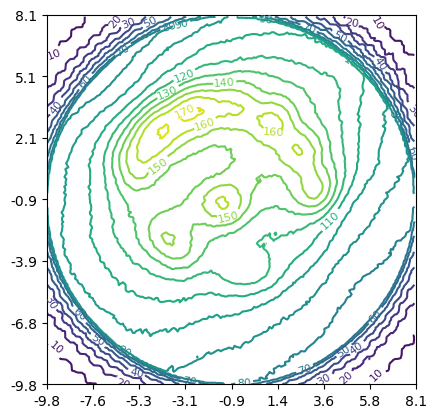

In [23]:
fig, ax = plt.subplots()

num_lines = 20
flipped = normalized[::-1] # This is Python sorcery that flips the data vertically so that it matches the other plots.
con = ax.contour(normalized,levels=num_lines)
ax.set_aspect('equal')
ax.clabel(con, inline=True, fontsize=8) 
ax.set_xticks(np.linspace(0,len(sinogram[0]),n_x_ticks))
ax.set_xticklabels(x_tick_labels)
ax.set_yticks(np.linspace(0,len(sinogram[0]),n_y_ticks))
ax.set_yticklabels(y_tick_labels);

plt.show()

Another useful option is to make a 3d projection of the sinogram

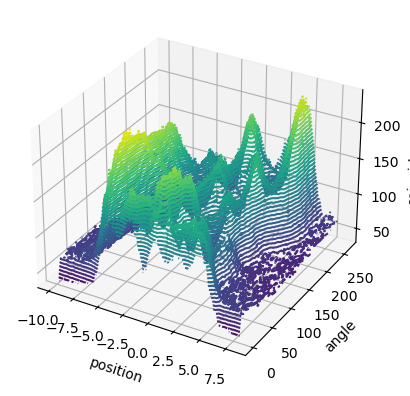

In [24]:
P,A = np.meshgrid(positions,angle_vals)
raw_sinogram = data.pivot_table('rate', 'thetaconverted', 'xconverted', fill_value=0).values
fig = plt.figure()
ax = plt.axes(projection='3d')

# Adjust the following as needed
min_counts = 10

truncated = np.where(raw_sinogram>min_counts,raw_sinogram,np.zeros_like(raw_sinogram)) # This takes out areas where the counts are less than 10
ax.contour3D(P, A, truncated ,50)
ax.set_xlabel('position')
ax.set_ylabel('angle')
ax.set_zlabel('coincidences');
plt.show()

Or, we can make a 3d plot of the final reconstruction

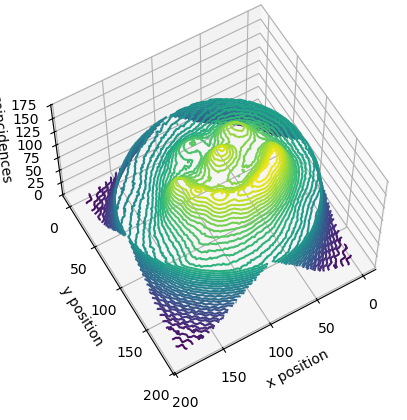

In [25]:
#X, Y= np.meshgrid(positions,positions)
lx = np.arange(0,len(normalized))
X, Y = np.meshgrid(lx,lx)

# This is tweaked because the reconstruction dimensions are a bit different 
# The X and Y are now in terms of array variables, not centimeters.

fig = plt.figure()
ax = plt.axes(projection='3d')
ax.contour3D(X,Y,normalized ,50)
#ax.plot_surface(X, Y, normalized, rstride=5, cstride=5) # alternate visualization mode
ax.set_xlabel('x position')
ax.set_ylabel('y position')
ax.set_zlabel('coincidences');
ax.view_init(elev=60,azim=60) # Edit these angles to rotate the camera view
plt.show()

We can also do this for each of our slices, giving a 3d view of how our reconstruction step-by-step.

# Advanced Techniques
----

We can also use a professional reconstruction technique: a [radon transform](https://en.wikipedia.org/wiki/Radon_transform).  At heart this technique uses a Fourier transform of slices, recombines these in a polar format, and then does an inverse Fourier transform.  You can try and work this out for yourself, but we can also use a package from `skimage` to do this for us with our data.  Since we're starting with slice/angle data, we'll be doing an inverse transformation.  See [this link](https://scikit-image.org/docs/stable/auto_examples/transform/plot_radon_transform.html) for more on how the `iradon` function works.

You'll need to install the `skimage` package in Anaconda for this to work.

The following shows what the inverse radon transform does, and then shows the difference between it and our reconstruction.  The results are normalized to a maximum coincidence rate of `1` to make the shapes comparable.

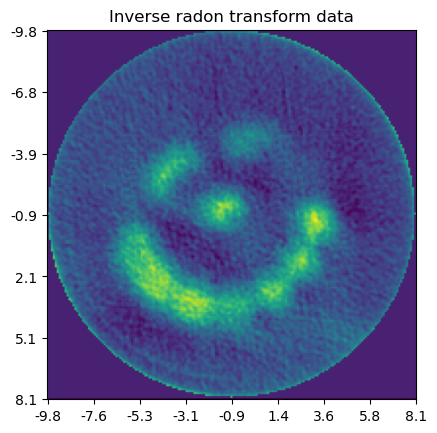

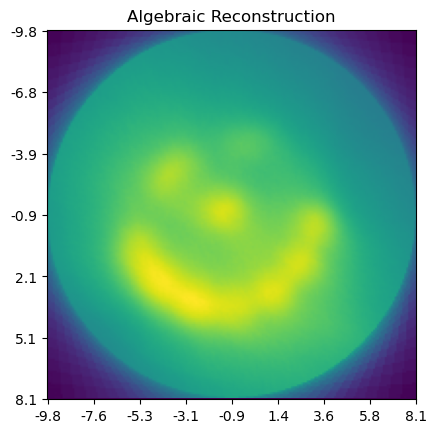

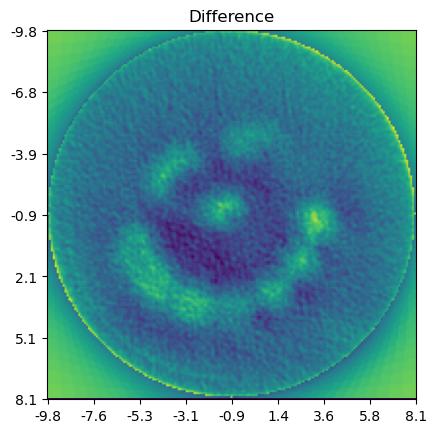

In [26]:
from skimage.transform import iradon
# the possible filters are 'ramp', 'shepp-logan', 'cosine', 'hamming', and 'hann'
try:
    reconstruction = iradon(sinogram.T,theta=np.unique(data['thetaconverted'].values),filter_name='cosine')
except: 
    reconstruction = iradon(sinogram.T,theta=np.unique(data['thetaconverted'].values))
    # Older versions of skimage don't use the filter_name argument.
# the transpose makes it line up with our other method
fig, ax = plt.subplots()
ax.imshow(reconstruction/np.max(reconstruction))
ax.set_title("Inverse radon transform data");
ax.set_xticks(np.linspace(0,len(sinogram[0]),n_x_ticks))
ax.set_xticklabels(x_tick_labels)
ax.set_yticks(np.linspace(0,len(sinogram[0]),n_y_ticks))
ax.set_yticklabels(y_tick_labels);
ax.set_facecolor(default_bkg)

fig,ax = plt.subplots()
ax.imshow(normalized/np.max(normalized))
ax.set_title("Algebraic Reconstruction")
ax.set_xticks(np.linspace(0,len(sinogram[0]),n_x_ticks))
ax.set_xticklabels(x_tick_labels)
ax.set_yticks(np.linspace(0,len(sinogram[0]),n_y_ticks))
ax.set_yticklabels(y_tick_labels);
ax.set_facecolor(default_bkg)

fig, ax = plt.subplots()
ax.imshow(reconstruction/np.max(reconstruction)-normalized/np.max(normalized))
ax.set_title("Difference")
ax.set_xticks(np.linspace(0,len(sinogram[0]),n_x_ticks))
ax.set_xticklabels(x_tick_labels)
ax.set_yticks(np.linspace(0,len(sinogram[0]),n_y_ticks))
ax.set_yticklabels(y_tick_labels);
ax.set_facecolor(default_bkg)

plt.show()

Now this can be hard to interpret, so we'll check out what happens when we make a 3D plot.

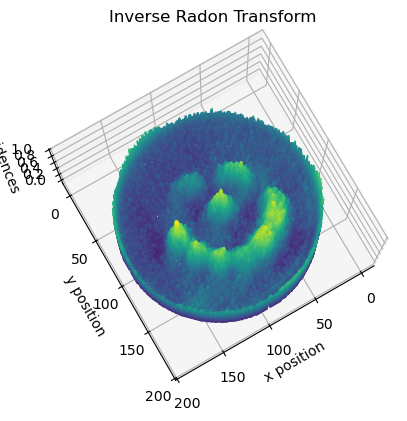

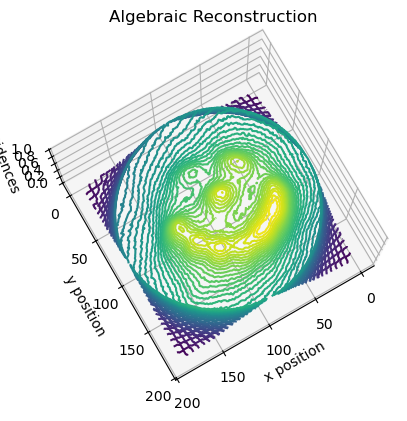

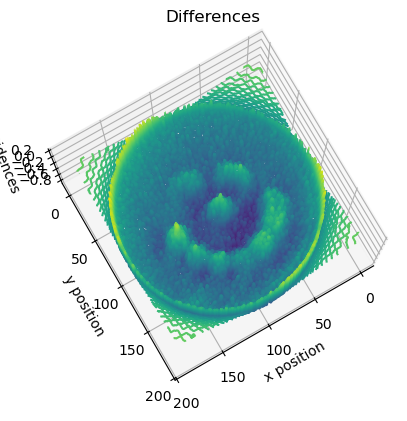

In [27]:
#X, Y= np.meshgrid(positions,positions)
lx = np.arange(0,len(normalized))
X, Y = np.meshgrid(lx,lx)

fig = plt.figure()
ax = plt.axes(projection='3d')
ax.contour3D(X,Y,reconstruction/np.max(reconstruction),50)
ax.set_xlabel('x position')
ax.set_ylabel('y position')
ax.set_zlabel('coincidences');
ax.set_title("Inverse Radon Transform")
ax.view_init(elev=80,azim=60)

#X, Y= np.meshgrid(positions,positions)
fig = plt.figure()
ax = plt.axes(projection='3d')
ax.contour3D(X,Y,normalized/np.max(normalized),50)
ax.set_xlabel('x position')
ax.set_ylabel('y position')
ax.set_zlabel('coincidences');
ax.set_title("Algebraic Reconstruction")
ax.view_init(elev=80,azim=60)

#X, Y= np.meshgrid(positions,positions)
fig = plt.figure()
ax = plt.axes(projection='3d')
ax.contour3D(X,Y,reconstruction/np.max(reconstruction)-normalized/np.max(normalized),50)
ax.set_xlabel('x position')
ax.set_ylabel('y position')
ax.set_zlabel('coincidences');
ax.set_title("Differences")
ax.view_init(elev=80,azim=60)

plt.show()